In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report,f1_score,ConfusionMatrixDisplay,accuracy_score

In [3]:
data_df = pd.read_csv('E:\\PythonCertificates\\IPL prediction application\\ipl.csv')

In [4]:
data_df.head(5)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bangalore,Kolkata Knight Riders,2008-04-18,Royal Challengers Bangalore,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Kings XI Punjab,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Daredevils,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Daredevils,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bangalore,2008-04-20,Mumbai Indians,bat,Royal Challengers Bangalore,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N


In [5]:
data_df.shape

(1169, 19)

In [6]:
data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1169 entries, 0 to 1168
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   team1            1169 non-null   str    
 1   team2            1169 non-null   str    
 2   match_date       1169 non-null   str    
 3   toss_winner      1169 non-null   str    
 4   toss_decision    1169 non-null   str    
 5   winner           1146 non-null   str    
 6   player_of_match  1169 non-null   str    
 7   venue            1169 non-null   str    
 8   city             1118 non-null   str    
 9   team1_players    1169 non-null   str    
 10  team2_players    1169 non-null   str    
 11  season           1169 non-null   int64  
 12  match_number     1169 non-null   int64  
 13  match_type       1169 non-null   str    
 14  result           1169 non-null   str    
 15  result_margin    1146 non-null   float64
 16  target_runs      1163 non-null   float64
 17  target_overs     1163 non

In [7]:
data_df.describe()

,season,match_number,result_margin,target_runs,target_overs
count,1169.000000,1169.000000,1146.000000,1163.000000,1163.000000
mean,9.687767,33.359281,17.364747,167.253654,19.768014
std,5.253100,19.430749,21.919255,34.222771,1.542583
min,1.000000,1.000000,1.000000,43.000000,5.000000
25%,5.000000,17.000000,6.000000,147.000000,20.000000
50%,10.000000,33.000000,8.000000,167.000000,20.000000
75%,15.000000,49.000000,20.000000,188.000000,20.000000
max,18.000000,76.000000,146.000000,288.000000,20.000000


In [8]:
data_df.isnull().sum().sort_values(ascending=False)

city               51
winner             23
result_margin      23
target_overs        6
target_runs         6
team1               0
team2               0
match_date          0
player_of_match     0
toss_decision       0
toss_winner         0
team2_players       0
team1_players       0
venue               0
season              0
result              0
match_type          0
match_number        0
super_over          0
dtype: int64

In [9]:
data_df.replace({
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}, inplace=True)

,team1,team2,match_date,toss_winner,toss_decision,winner,player_of_match,venue,city,team1_players,team2_players,season,match_number,match_type,result,result_margin,target_runs,target_overs,super_over
0,Royal Challengers Bengaluru,Kolkata Knight Riders,2008-04-18,Royal Challengers Bengaluru,field,Kolkata Knight Riders,BB McCullum,M Chinnaswamy Stadium,Bangalore,"R Dravid, W Jaffer, V Kohli, JH Kallis, CL Whi...","SC Ganguly, BB McCullum, RT Ponting, DJ Hussey...",1,1,League,runs,140.0,223.0,20.0,N
1,Punjab Kings,Chennai Super Kings,2008-04-19,Chennai Super Kings,bat,Chennai Super Kings,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Chandigarh,"K Goel, JR Hopes, KC Sangakkara, Yuvraj Singh,...","PA Patel, ML Hayden, MEK Hussey, MS Dhoni, SK ...",1,2,League,runs,33.0,241.0,20.0,N
2,Delhi Capitals,Rajasthan Royals,2008-04-19,Rajasthan Royals,bat,Delhi Capitals,MF Maharoof,Feroz Shah Kotla,Delhi,"G Gambhir, V Sehwag, S Dhawan, MK Tiwary, KD K...","T Kohli, YK Pathan, SR Watson, M Kaif, DS Lehm...",1,3,League,wickets,9.0,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bengaluru,2008-04-20,Mumbai Indians,bat,Royal Challengers Bengaluru,MV Boucher,Wankhede Stadium,Mumbai,"L Ronchi, ST Jayasuriya, DJ Thornely, RV Uthap...","S Chanderpaul, R Dravid, LRPL Taylor, JH Kalli...",1,4,League,wickets,5.0,166.0,20.0,N
4,Kolkata Knight Riders,Deccan Chargers,2008-04-20,Deccan Chargers,bat,Kolkata Knight Riders,DJ Hussey,Eden Gardens,Kolkata,"WP Saha, BB McCullum, RT Ponting, SC Ganguly, ...","AC Gilchrist, Y Venugopal Rao, VVS Laxman, A S...",1,5,League,wickets,5.0,111.0,20.0,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,Lucknow Super Giants,Royal Challengers Bengaluru,2025-05-27,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,JM Sharma,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,Lucknow,"Akash Singh, MR Marsh, MP Breetzke, RR Pant, N...","Suyash Sharma, PD Salt, V Kohli, RM Patidar, L...",18,70,League,wickets,6.0,228.0,20.0,N
1165,Punjab Kings,Royal Challengers Bengaluru,2025-05-29,Royal Challengers Bengaluru,field,Royal Challengers Bengaluru,Suyash Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,"Priyansh Arya, P Simran Singh, JP Inglis, SS I...","Suyash Sharma, PD Salt, V Kohli, MA Agarwal, R...",18,71,Qualifier 1,wickets,8.0,102.0,20.0,N
1166,Mumbai Indians,Gujarat Titans,2025-05-30,Mumbai Indians,bat,Mumbai Indians,RG Sharma,Maharaja Yadavindra Singh International Cricke...,New Chandigarh,"Ashwani Kumar, RG Sharma, JM Bairstow, SA Yada...","Mohammed Siraj, B Sai Sudharsan, Shubman Gill,...",18,72,Eliminator,runs,20.0,229.0,20.0,N
1167,Mumbai Indians,Punjab Kings,2025-06-01,Punjab Kings,field,Punjab Kings,SS Iyer,"Narendra Modi Stadium, Ahmedabad",Ahmedabad,"Ashwani Kumar, RG Sharma, JM Bairstow, Tilak V...","YS Chahal, Priyansh Arya, P Simran Singh, JP I...",18,73,Qualifier 2,wickets,5.0,204.0,20.0,N


In [10]:
data_df = data_df[data_df['winner'].notna()]

In [11]:
data_df['winner'].value_counts()

winner
Mumbai Indians                 151
Chennai Super Kings            142
Kolkata Knight Riders          135
Royal Challengers Bengaluru    132
Punjab Kings                   119
Delhi Capitals                 118
Rajasthan Royals               114
Sunrisers Hyderabad             93
Gujarat Titans                  37
Lucknow Super Giants            30
Deccan Chargers                 29
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64

In [12]:
team1_wins = data_df[data_df['winner'] == data_df['team1']].shape[0]
team2_wins = data_df[data_df['winner'] == data_df['team2']].shape[0]

print("Team1 Wins:", team1_wins)
print("Team2 Wins:", team2_wins)

Team1 Wins: 581
Team2 Wins: 565


In [13]:
toss_win_match_win = data_df[data_df['toss_winner'] == data_df['winner']].shape[0]
total_matches = data_df.shape[0]

print("Toss winner also won match %:",
      toss_win_match_win/total_matches * 100)

Toss winner also won match %: 51.57068062827225


<Figure size 1600x800 with 0 Axes>

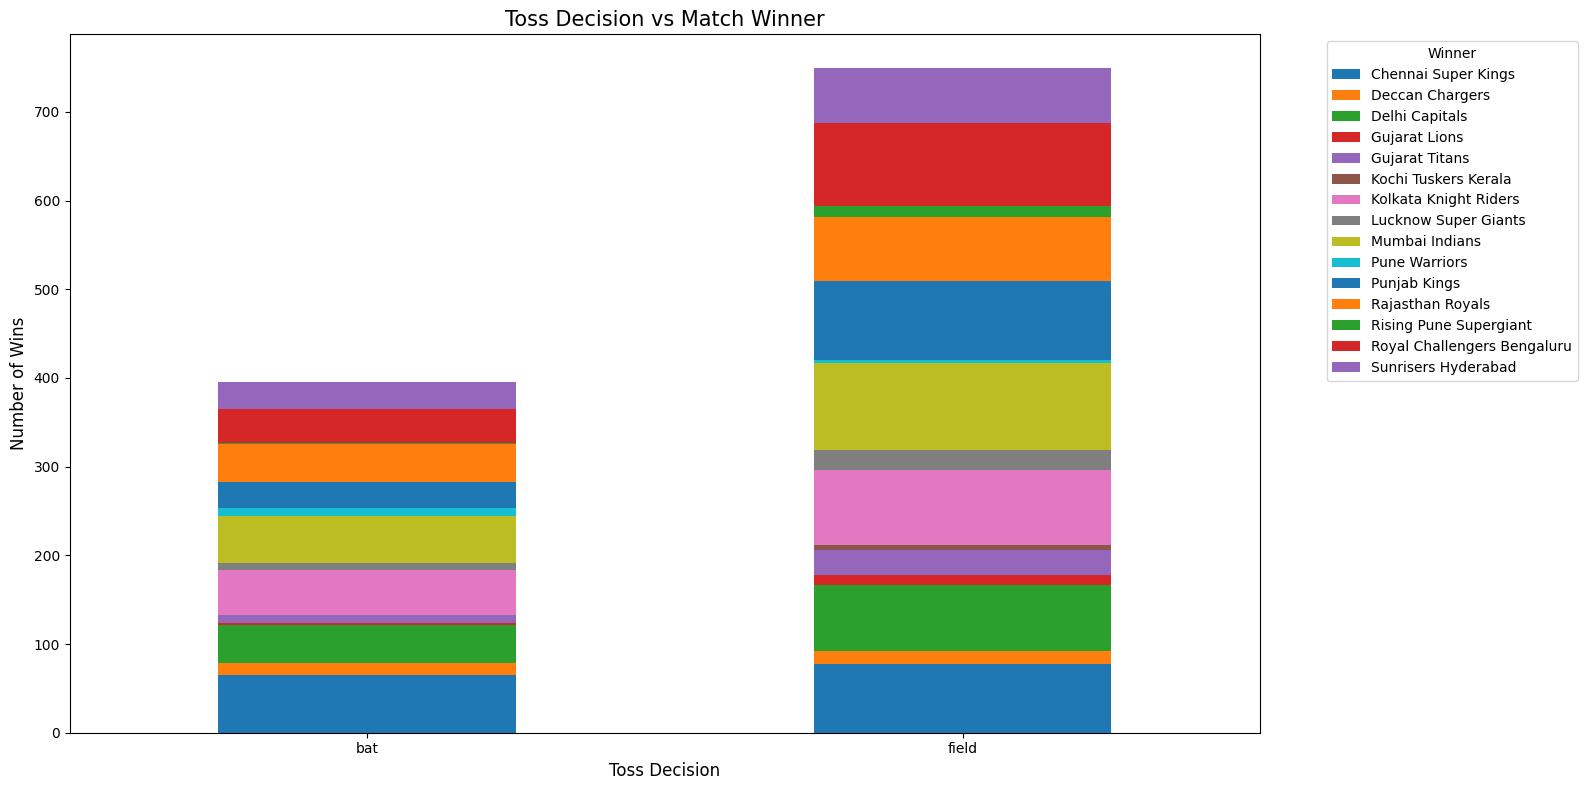

In [14]:
plt.figure(figsize=(16, 8)) 

ax = pd.crosstab(data_df['toss_decision'], data_df['winner']).plot(
    kind='bar', 
    stacked=True, 
    figsize=(16, 8)
)

plt.title("Toss Decision vs Match Winner", fontsize=15)
plt.xlabel("Toss Decision", fontsize=12)
plt.ylabel("Number of Wins", fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Winner', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [15]:
pd.crosstab(data_df['venue'], data_df['winner'])

winner,Chennai Super Kings,Deccan Chargers,Delhi Capitals,Gujarat Lions,Gujarat Titans,Kochi Tuskers Kerala,Kolkata Knight Riders,Lucknow Super Giants,Mumbai Indians,Pune Warriors,Punjab Kings,Rajasthan Royals,Rising Pune Supergiant,Royal Challengers Bengaluru,Sunrisers Hyderabad
venue,,,,,,,,,,,,,,,
Arun Jaitley Stadium,1,0,7,0,0,0,0,0,1,0,1,0,0,1,2
"Arun Jaitley Stadium, Delhi",2,0,6,0,2,0,1,0,4,0,1,2,0,1,3
Barabati Stadium,0,3,0,0,0,0,3,0,0,0,1,0,0,0,0
"Barsapara Cricket Stadium, Guwahati",0,0,0,0,0,0,1,0,0,0,2,2,0,0,0
"Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow",1,0,2,0,1,0,1,9,0,0,2,1,0,2,2
Brabourne Stadium,1,0,0,0,0,0,0,0,5,0,0,2,0,1,1
"Brabourne Stadium, Mumbai",0,0,4,0,2,0,0,2,2,0,2,3,0,0,2
Buffalo Park,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0
De Beers Diamond Oval,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0


In [16]:
data_df['venue'].value_counts()

venue
Eden Gardens                                                               77
Wankhede Stadium                                                           72
M Chinnaswamy Stadium                                                      62
Feroz Shah Kotla                                                           59
Wankhede Stadium, Mumbai                                                   52
Rajiv Gandhi International Stadium, Uppal                                  48
Sawai Mansingh Stadium                                                     47
MA Chidambaram Stadium, Chepauk                                            47
Dubai International Cricket Stadium                                        43
Punjab Cricket Association Stadium, Mohali                                 35
MA Chidambaram Stadium, Chepauk, Chennai                                   33
Narendra Modi Stadium, Ahmedabad                                           33
Sharjah Cricket Stadium                                   

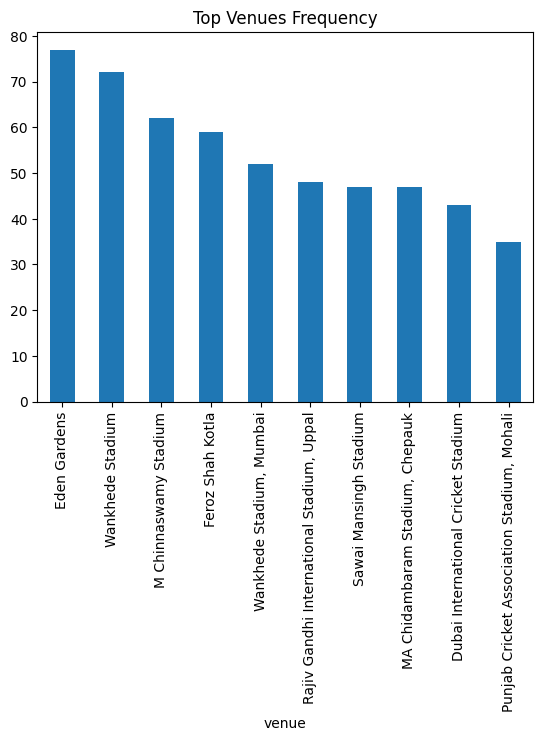

In [17]:
data_df['venue'].value_counts().head(10).plot(kind='bar')
plt.title("Top Venues Frequency")
plt.show()

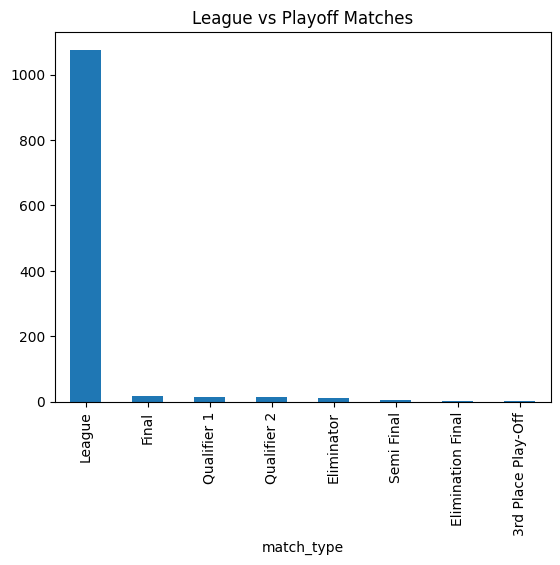

In [18]:
data_df['match_type'].value_counts().plot(kind='bar')
plt.title("League vs Playoff Matches")
plt.show()

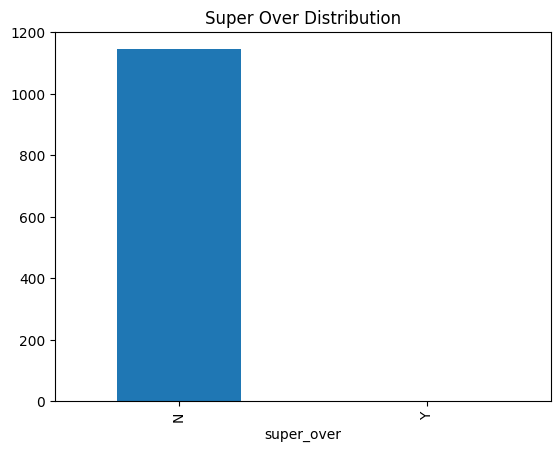

In [19]:
data_df['super_over'].value_counts().plot(kind='bar')
plt.title("Super Over Distribution")
plt.show()

In [20]:
obsolete_teams = [
    'Deccan Chargers',
    'Gujarat Lions',
    'Pune Warriors',
    'Kochi Tuskers Kerala',
    'Rising Pune Supergiant'
]

for col in ['team1', 'team2', 'toss_winner', 'winner']:
    data_df = data_df[~data_df[col].isin(obsolete_teams)]

In [21]:
data_df.drop([
    'player_of_match',
    'result',
    'result_margin',
    'match_date',
    'team1_players',
    'team2_players'
], axis=1, inplace=True)


In [22]:
data_df.head(10)

,team1,team2,toss_winner,toss_decision,winner,venue,city,season,match_number,match_type,target_runs,target_overs,super_over
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,M Chinnaswamy Stadium,Bangalore,1,1,League,223.0,20.0,N
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,1,2,League,241.0,20.0,N
2,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,Feroz Shah Kotla,Delhi,1,3,League,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,Wankhede Stadium,Mumbai,1,4,League,166.0,20.0,N
5,Rajasthan Royals,Punjab Kings,Punjab Kings,bat,Rajasthan Royals,Sawai Mansingh Stadium,Jaipur,1,6,League,167.0,20.0,N
7,Chennai Super Kings,Mumbai Indians,Mumbai Indians,field,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",Chennai,1,8,League,209.0,20.0,N
9,Punjab Kings,Mumbai Indians,Mumbai Indians,field,Punjab Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,1,10,League,183.0,20.0,N
10,Chennai Super Kings,Kolkata Knight Riders,Kolkata Knight Riders,bat,Chennai Super Kings,"MA Chidambaram Stadium, Chepauk",Chennai,1,11,League,136.0,20.0,N
11,Royal Challengers Bengaluru,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,M Chinnaswamy Stadium,Bangalore,1,12,League,148.0,20.0,N
13,Punjab Kings,Delhi Capitals,Delhi Capitals,bat,Punjab Kings,"Punjab Cricket Association Stadium, Mohali",Chandigarh,1,14,League,159.0,20.0,N


In [23]:
data_df['target_runs'] = data_df['target_runs'].fillna(0)
data_df['target_overs'] = data_df['target_overs'].fillna(0)


In [24]:
data_df.drop('city', axis=1, inplace=True)

In [25]:
data_df.head(4)

,team1,team2,toss_winner,toss_decision,winner,venue,season,match_number,match_type,target_runs,target_overs,super_over
0,Royal Challengers Bengaluru,Kolkata Knight Riders,Royal Challengers Bengaluru,field,Kolkata Knight Riders,M Chinnaswamy Stadium,1,1,League,223.0,20.0,N
1,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",1,2,League,241.0,20.0,N
2,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Delhi Capitals,Feroz Shah Kotla,1,3,League,130.0,20.0,N
3,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Royal Challengers Bengaluru,Wankhede Stadium,1,4,League,166.0,20.0,N


In [26]:
data_df.drop('match_number', axis=1, inplace=True)

In [27]:
data_df['target_runs'] = data_df['target_runs'].astype(int)
data_df['target_overs'] = data_df['target_overs'].astype(int)

In [28]:
features = data_df.drop('winner', axis=1)
target = data_df['winner']


In [29]:
categorical_cols = [
    'team1',
    'team2',
    'toss_winner',
    'toss_decision',
    'venue',
    'match_type',
    'super_over'
]

numerical_cols = [
    'season',
    'target_runs',
    'target_overs'
]

In [30]:
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=365, stratify=target)

In [31]:
categorical_coloumns = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])
numerical_coloumns = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])


In [32]:
preprocessor = ColumnTransformer(transformers=[('cat', categorical_coloumns, categorical_cols),
                                              ('num', numerical_coloumns, numerical_cols)])

In [33]:
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('model', RandomForestClassifier(class_weight='balanced', random_state=365))])

In [34]:
parameter = {'model__n_estimators': [200, 400, 600],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__bootstrap': [True, False]}

In [35]:
gridsearch = GridSearchCV(rf_pipeline, param_grid=parameter, cv=5,scoring='f1_weighted', n_jobs=-1)

In [36]:
gridsearch.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._state=365))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__bootstrap': [True, False], 'model__max_depth': [10, 20, ...], 'model__max_features': ['sqrt', 'log2'], 'model__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the co

In [37]:
best_model = gridsearch.best_estimator_

In [38]:
y_predicted = best_model.predict(x_test)

In [39]:
y_predicted

array(['Chennai Super Kings', 'Royal Challengers Bengaluru',
       'Kolkata Knight Riders', 'Rajasthan Royals', 'Sunrisers Hyderabad',
       'Delhi Capitals', 'Chennai Super Kings', 'Chennai Super Kings',
       'Sunrisers Hyderabad', 'Gujarat Titans', 'Lucknow Super Giants',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Rajasthan Royals',
       'Chennai Super Kings', 'Mumbai Indians', 'Chennai Super Kings',
       'Royal Challengers Bengaluru', 'Delhi Capitals',
       'Chennai Super Kings', 'Chennai Super Kings', 'Punjab Kings',
       'Royal Challengers Bengaluru', 'Rajasthan Royals',
       'Rajasthan Royals', 'Lucknow Super Giants', 'Chennai Super Kings',
       'Mumbai Indians', 'Mumbai Indians', 'Punjab Kings',
       'Lucknow Super Giants', 'Punjab Kings', 'Sunrisers Hyderabad',
       'Sunrisers Hyderabad', 'Gujarat Titans', 'Rajasthan Royals',
       'Kolkata Knight Riders', 'Rajasthan Royals',
       'Kolkata Knight Riders', 'Royal Challengers Bengaluru',
       'Che

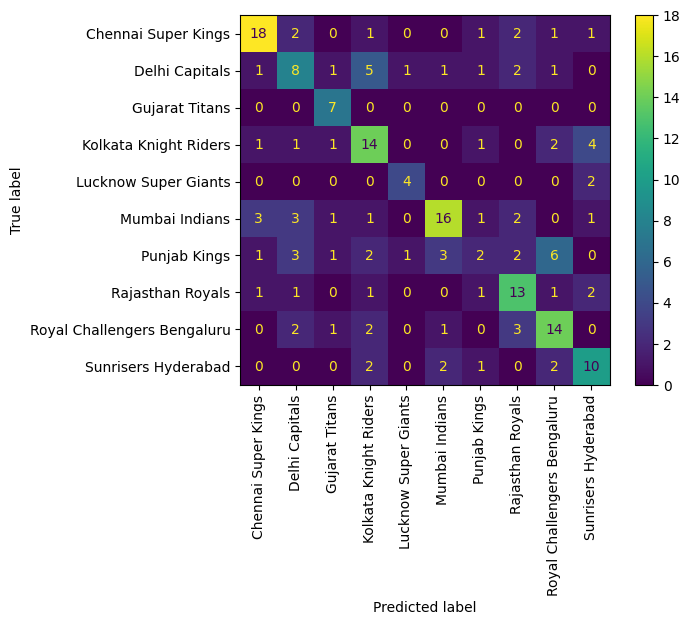

In [40]:
plt.Figure(figsize=(16,12))
ConfusionMatrixDisplay.from_predictions(y_test, y_predicted)
plt.xticks(rotation=90)
plt.show()

In [41]:
print(classification_report(y_test, y_predicted))

                             precision    recall  f1-score   support

        Chennai Super Kings       0.72      0.69      0.71        26
             Delhi Capitals       0.40      0.38      0.39        21
             Gujarat Titans       0.58      1.00      0.74         7
      Kolkata Knight Riders       0.50      0.58      0.54        24
       Lucknow Super Giants       0.67      0.67      0.67         6
             Mumbai Indians       0.70      0.57      0.63        28
               Punjab Kings       0.25      0.10      0.14        21
           Rajasthan Royals       0.54      0.65      0.59        20
Royal Challengers Bengaluru       0.52      0.61      0.56        23
        Sunrisers Hyderabad       0.50      0.59      0.54        17

                   accuracy                           0.55       193
                  macro avg       0.54      0.58      0.55       193
               weighted avg       0.53      0.55      0.53       193



In [46]:
new_match = pd.DataFrame({
    'team1': ['Chennai Super Kings'],
    'team2': ['Royal Challengers Bengaluru'],
    'toss_winner': ['Chennai Super Kings'],
    'toss_decision': ['bat'],
    'venue': ['M Chinnaswamy Stadium'],
    'match_type': ['League'],
    'season': [17],
    'target_runs': [220],
    'target_overs': [20],
    'super_over': ['N']
})

In [45]:
predicted_winner = best_model.predict(new_match)
print("Predicted Winner:", predicted_winner[0])

Predicted Winner: Chennai Super Kings
